<P> <img src="https://i.ibb.co/gyNf19D/nhslogo.png" alt="nhslogo" border="0" width="100" align="right"><font size="6"><b> CS4132 Data Analytics</b> </font>

# Lab 7.2: Data Exploration II (Multivariate Data)

### Submission Instructions

* Complete the following questions and upload your `.ipynb` file to Coursemology.
* Name the file in the following format: `Lab<num><YourName>.ipynb`
* Before submitting, please ensure you click on "Kernel" > "Restart and Run All" on your jupyter notebook. 
* Finally, print a copy of your final solution to OneNote > Your Individual Student Notebook > Labs. Name the page `Lab <num>`.

## Q1

Manatees are large, gentle sea creatures that live along the Florida coast. Many manatees are killed or injured by powerboats. The data on powerboat registrations (in thousands) and the number of manatees killed by boats in Florida in the years 1977 to 1990 is given below:

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import *
import seaborn as sns
df = pd.read_csv("Lab7iiQ1.csv")
df

,Year,Powerboat Registration,Manatees Killed
0,1977,447,13
1,1978,460,21
2,1979,481,24
3,1980,498,16
4,1981,513,24
5,1982,512,20
6,1983,526,15
7,1984,559,34
8,1985,585,33
9,1986,614,33


#### a) Draw a relevant scatterplot of these data.

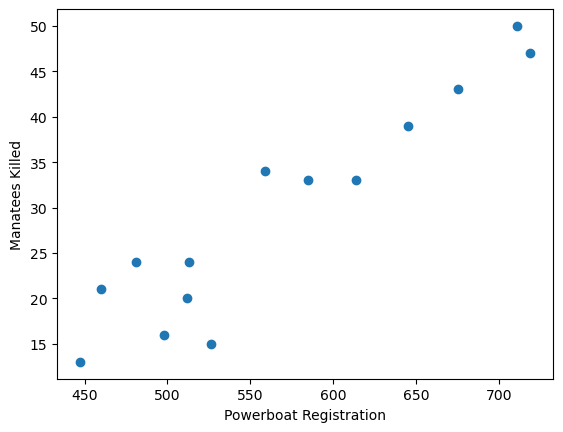

In [191]:
#your solution
plt.scatter(df['Powerboat Registration'], df['Manatees Killed'])
plt.xlabel('Powerboat Registration')
plt.ylabel('Manatees Killed')
plt.show()

#### b) Find the correlation between number of powerboat registration and number of manatees killed. Conclude your findings.

In [192]:
#your solution
pearson_coef = pearsonr(df['Powerboat Registration'], df['Manatees Killed'])[0]
print('r = ', pearson_coef)
print('r^2 = ', pearson_coef**2)

r =  0.9414772887893057
r^2 =  0.8863794853060617


#### c) Describe your findings from (a) and (b).

    There is a strong positive linear correlation between number of powerboat registration and the number of manatees killed. That means the more powerboats are registered, the higher the number of manatees killed.

#### d) Plot a regression line for on the scatterplot.

<Axes: xlabel='Powerboat Registration', ylabel='Manatees Killed'>

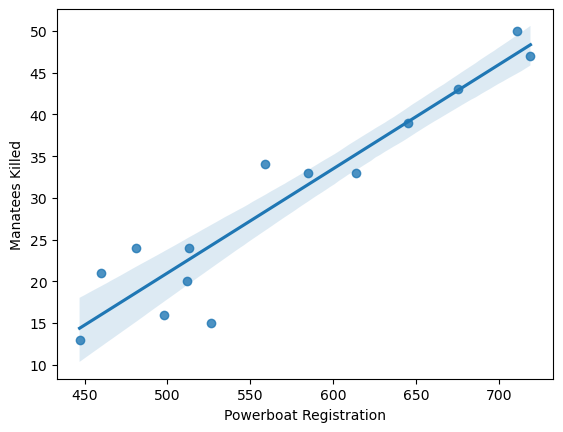

In [193]:
#your solution
sns.regplot(x = df['Powerboat Registration'], y = df['Manatees Killed'], data = df)

#### e) Create a pairplot for the data given.

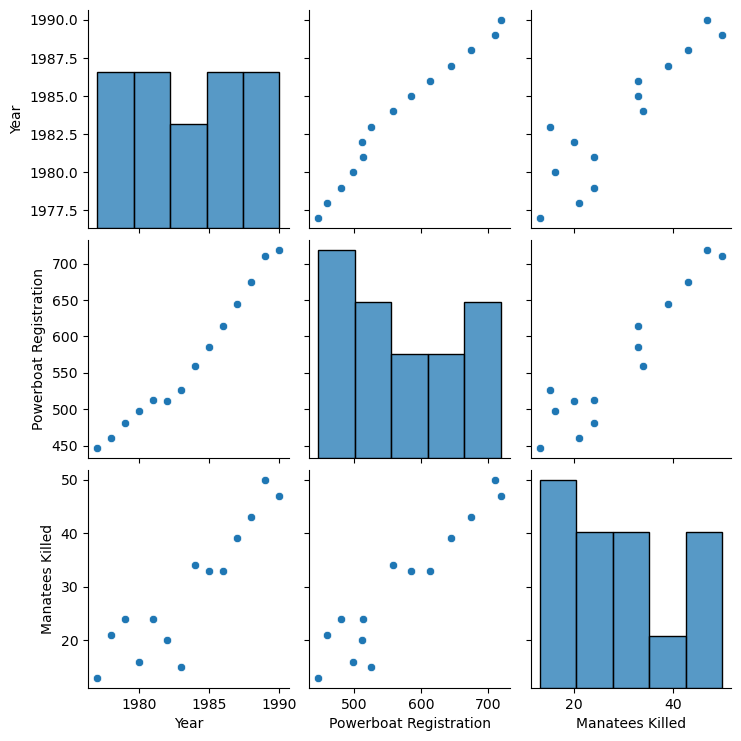

In [194]:
#your solution
sns.pairplot(df)

## Q2

In this question, we will use the World Happiness Report, which is a survey about the state of global happiness. The data is imported as follows:

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import *
import seaborn as sns
data = pd.read_csv('Lab7iiQ2.csv', index_col=0)
data.sort_values(['Year', "Happiness Score"], ascending=[True, False], inplace=True)
data.head()

,Country,Region,Happiness Rank,Happiness Score,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Year
141,Switzerland,Western Europe,1.0,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
60,Iceland,Western Europe,2.0,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
38,Denmark,Western Europe,3.0,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
108,Norway,Western Europe,4.0,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
25,Canada,North America,5.0,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


Below is a short description of what each column means:
<ul>
<li><strong>Happiness Score:&nbsp;</strong>A metric measured in 2015 by asking the sampled people the question: "How would you rate your happiness on a scale of 0 to 10 where 10 is the happiest."</li>
<li><strong>Economy (GDP per Capita):&nbsp;</strong>The extent to which GDP contributes to the calculation of the Happiness Score.</li>
<li><strong>Family:&nbsp;</strong>The extent to which Family contributes to the calculation of the Happiness Score</li>
<li><strong>Health (Life Expectancy):&nbsp;</strong>The extent to which Life expectancy contributed to the calculation of the Happiness Score</li>
<li><strong>Freedom:&nbsp;</strong>The extent to which Freedom contributed to the calculation of the Happiness Score.</li>
<li><strong>Trust (Government Corruption):&nbsp;</strong>The extent to which Perception of Corruption contributes to Happiness Score.</li>
<li>
<div class="sc-kMZwpj dFFZuK"><strong><span class="sc-fznzOf sc-fznMnq sc-jRYQbI hmtEvs">Generosity:&nbsp;</span></strong><span class="sc-fznzOf sc-fznMnq sc-jRYQbI hmtEvs">The extent to which Generosity contributed to the calculation of the Happiness Score.</span></div>
</li>
</ul>

#### a) We will summarize the happiness score in this part (using mean).

i) Summarize the happiness score by year in a table.

In [196]:
#your solution
data.groupby('Year')['Happiness Score'].mean().to_frame()

,Happiness Score
Year,
2015,5.375734
2016,5.382185
2017,5.354019


ii) Summarize the happiness score by region in a table.

In [197]:
#your solution
data.groupby('Region')['Happiness Score'].mean().to_frame()

,Happiness Score
Region,
Australia and New Zealand,7.302500
Central and Eastern Europe,5.371184
Eastern Asia,5.632333
Latin America and Caribbean,6.069074
Middle East and Northern Africa,5.387879
North America,7.227167
Southeastern Asia,5.364077
Southern Asia,4.590857
Sub-Saharan Africa,4.150957


iii) Summarize the happiness score by region, per year in a table.


Sample output:
<table border="1" class="dataframe">
<thead>
<tr>
<th></th>
<th></th>
<th>Happiness Score</th>
</tr>
<tr>
<th>Region</th>
<th>Year</th>
<th></th>
</tr>
</thead>
<tbody>
<tr>
<td rowspan="3" valign="top">Australia and New Zealand</td>
<td>2015</td>
<td>7.285000</td>
</tr>
<tr>
<td>2016</td>
<td>7.323500</td>
</tr>
<tr>
<td>2017</td>
<td>7.299000</td>
</tr>
</tbody>
</table>

In [198]:
#your solution
data.groupby(['Region', 'Year'])['Happiness Score'].mean().to_frame()

Happiness Score
Region                          Year                 
Australia and New Zealand       2015         7.285000
                                2016         7.323500
                                2017         7.299000
Central and Eastern Europe      2015         5.332931
                                2016         5.370690
                                2017         5.409931
Eastern Asia                    2015         5.626167
                                2016         5.624167
                                2017         5.646667
Latin America and Caribbean     2015         6.144682
                                2016         6.101750
                                2017         5.957818
Middle East and Northern Africa 2015         5.406900
                                2016         5.386053
                                2017         5.369684
North America                   2015         7.273000
                                2016         7.254000
                                2017         7.154500
Southeastern Asia               2015         5.317444
                                2016         5.338889
                                2017         5.444875
Southern Asia                   2015         4.580857
                                2016         4.563286
                                2017         4.628429
Sub-Saharan Africa              2015         4.202800
                                2016         4.136421
                                2017         4.111949
Western Europe                  2015         6.689619
                                2016         6.685667
                                2017         6.703714

iv) Summarize the happiness score by region, per year similar to (c), but we would like the years to be in columns.

Sample output:
<table border="1" class="dataframe">
<thead>
<tr>
<th>Year</th>
<th>2015</th>
<th>2016</th>
<th>2017</th>
</tr>
<tr>
<th>Region</th>
<th></th>
<th></th>
<th></th>
</tr>
</thead>
<tbody>
<tr>
<td>Australia and New Zealand</td>
<td>7.285000</td>
<td>7.323500</td>
<td>7.299000</td>
</tr>
<tr>
<td>Central and Eastern Europe</td>
<td>5.332931</td>
<td>5.370690</td>
<td>5.409931</td>
</tr>
</tbody>
</table>

In [199]:
#your solution
pivot = pd.pivot_table(data, index = 'Region', columns='Year', values='Happiness Score')
pivot

Year,2015,2016,2017
Region,,,
Australia and New Zealand,7.285000,7.323500,7.299000
Central and Eastern Europe,5.332931,5.370690,5.409931
Eastern Asia,5.626167,5.624167,5.646667
Latin America and Caribbean,6.144682,6.101750,5.957818
Middle East and Northern Africa,5.406900,5.386053,5.369684
North America,7.273000,7.254000,7.154500
Southeastern Asia,5.317444,5.338889,5.444875
Southern Asia,4.580857,4.563286,4.628429
Sub-Saharan Africa,4.202800,4.136421,4.111949


#### Let's visualize the data in (iv)

Plot a suitable grouped bar chart for the data in (iv)

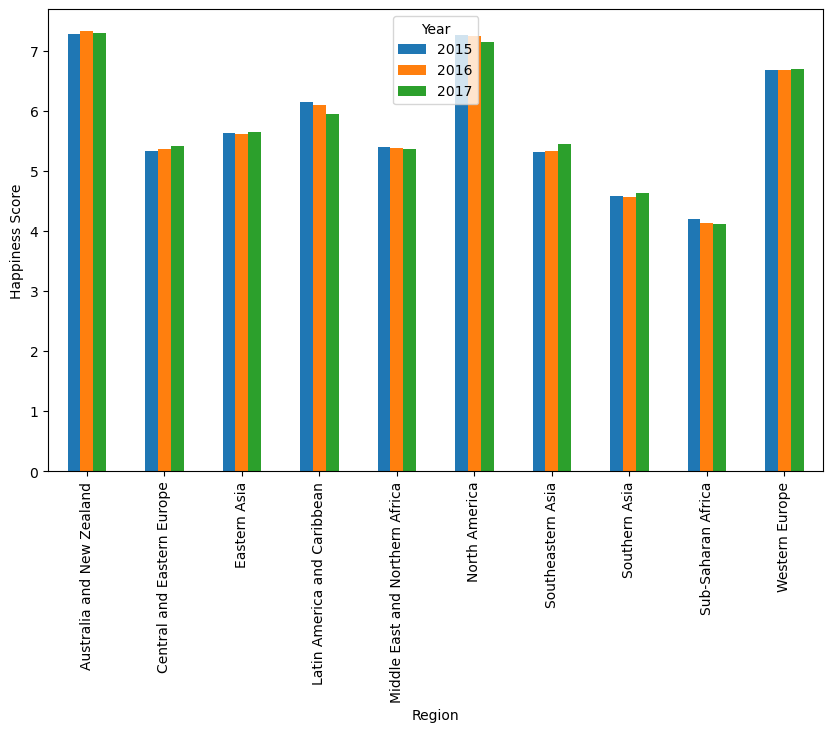

In [200]:
#your solution
pivot.plot(kind= 'bar', figsize=(10, 6))
plt.ylabel("Happiness Score")
plt.show()

Plot a suitable pointplot for the data in (iv)

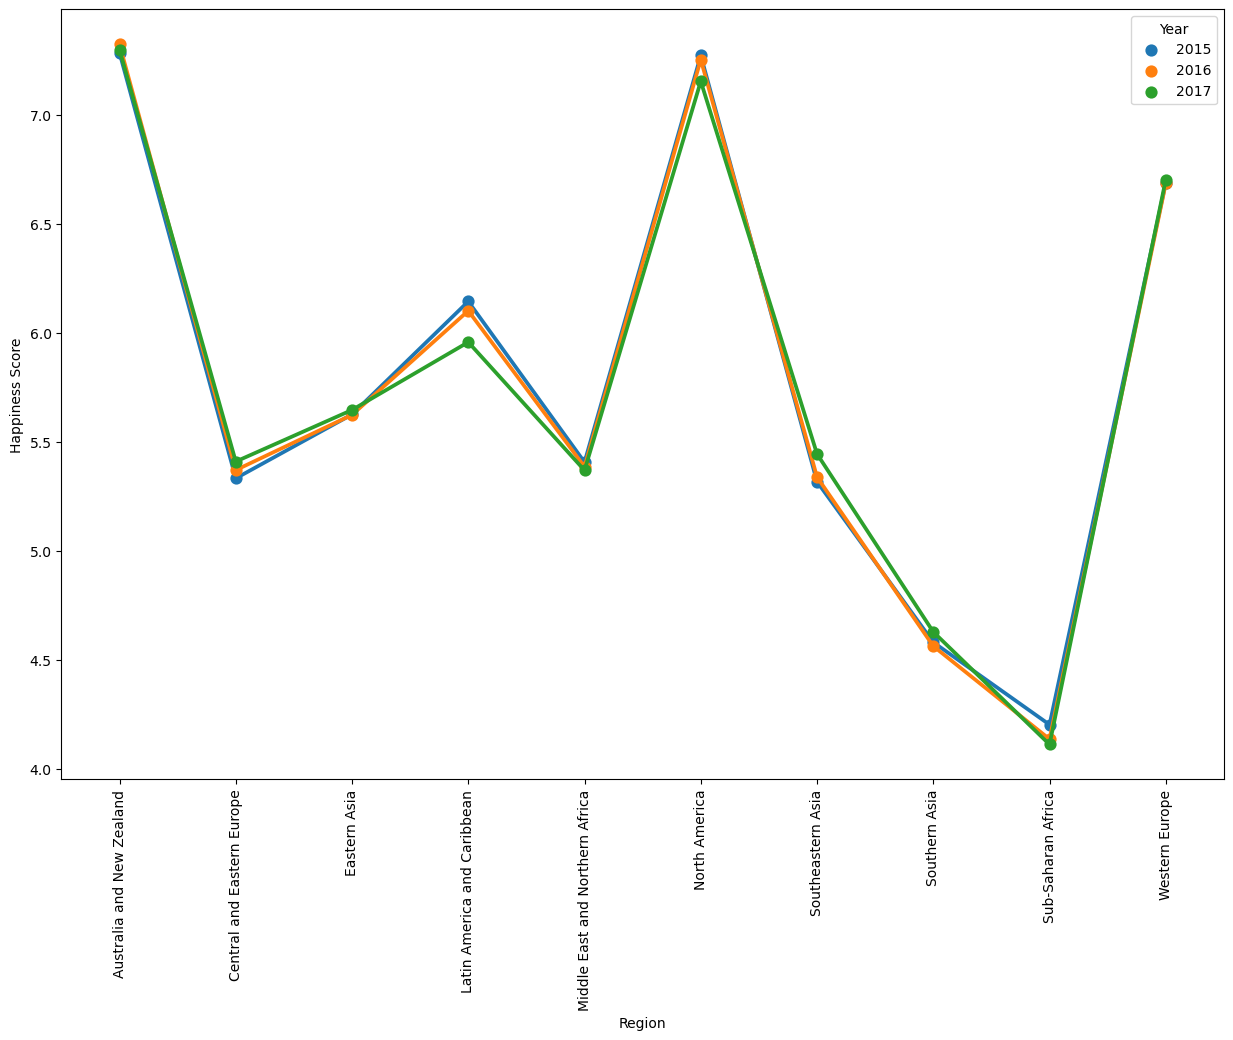

In [201]:
#your solution
plt.figure(figsize = (15, 10))
plt.xticks(rotation = 90)
sns.pointplot(x = 'Region', y = 'Happiness Score', hue = 'Year', data = pivot.reset_index().melt(id_vars = 'Region', value_name = 'Happiness Score'))
plt.show()

Hence, which plot do you think is a better visualization for data in (iv). Justify your answer clearly.

<div class="alert alert-block alert-info">

Grouped bar chart. We are not looking for trends over a period of time, and the points are very close together on the pointplot.
    
</div>

#### b) Perform relevant EDA to answer the following question:

Which of the six variables ['Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)','Freedom', 'Trust (Government Corruption)', 'Generosity'] most affect a country’s “happiness”?

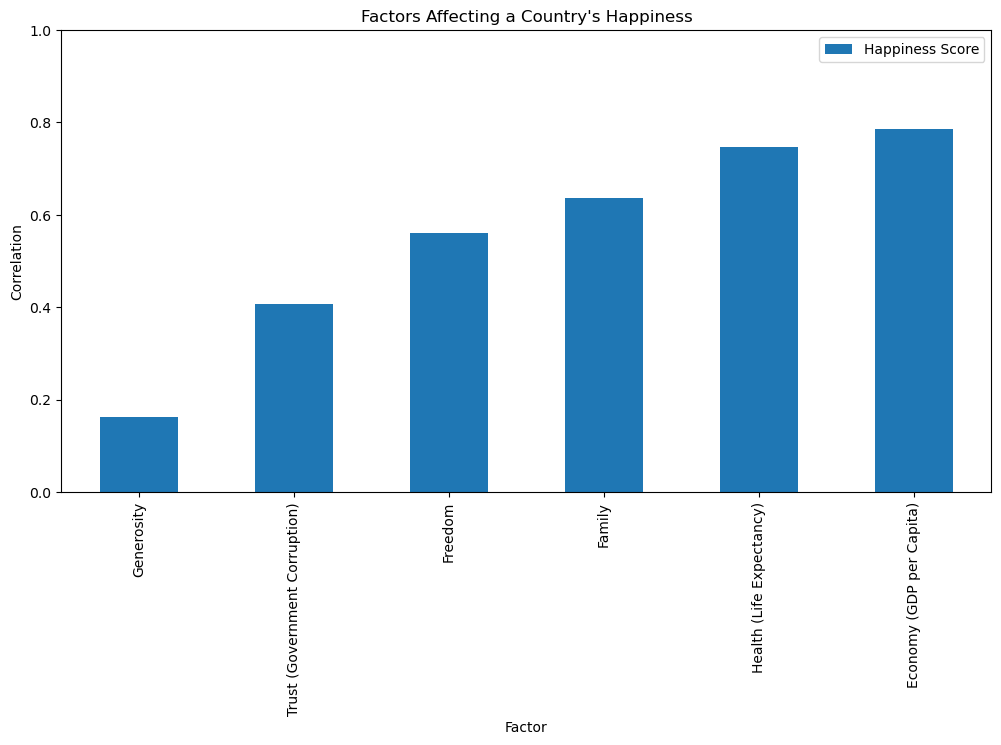

In [202]:
#your solution
columns = ['Happiness Score', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)','Freedom', 'Trust (Government Corruption)', 'Generosity']
newdata = data[columns]
newdata = newdata[(~newdata.Family.isnull())]
correlations = newdata[columns].corr().iloc[0, 1:].to_frame().sort_values(by = 'Happiness Score')
correlations.plot(kind='bar', figsize=(12, 6))
plt.title('Factors Affecting a Country\'s Happiness')
plt.xlabel('Factor')
plt.ylabel('Correlation')
plt.ylim((0, 1))
plt.show()

Justify your answer based on the insights gained from the plot.

<div class="alert alert-block alert-info">
GDP Per Capita.
The GDP Per Capita has the strongest postive linear correlation with a country's happiness and hence the highest value in the bar chart.
    
</div>

#### c) Find each factor's correlation with the overall happiness score. Store the data in a dataframe.

In [203]:
#your solution
factors = data.corr().loc['Happiness Score'].to_frame()
factors

C:\Users\user\AppData\Local\Temp\ipykernel_24836\1758012939.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  factors = data.corr().loc['Happiness Score'].to_frame()


,Happiness Score
Happiness Rank,-0.993268
Happiness Score,1.000000
Economy (GDP per Capita),0.785450
Family,0.636532
Health (Life Expectancy),0.748040
Freedom,0.560353
Trust (Government Corruption),0.406340
Generosity,0.163562
Year,-0.007761


#### d) Plot a bar graph to visualize the data in c)

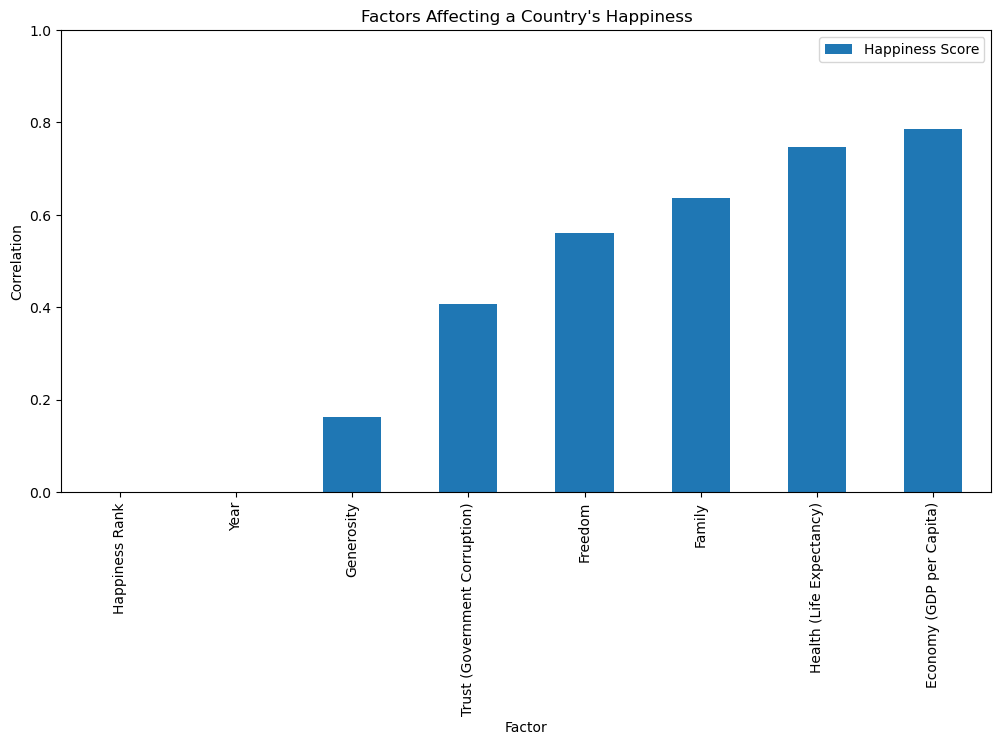

In [204]:
#your solution
factors = factors.loc[~factors.index.str.contains('Happiness Score')].sort_values(by = 'Happiness Score')
factors.plot(kind='bar', figsize=(12, 6))
plt.title('Factors Affecting a Country\'s Happiness')
plt.xlabel('Factor')
plt.ylabel('Correlation')
plt.ylim((0, 1))
plt.show()

#### e) You are to shortlist a question you wish to investigate (and not already covered above) using the data given.
Based on what you have learnt thus far, perform relevant EDA to help answer your question.

C:\Users\user\AppData\Local\Temp\ipykernel_24836\258552304.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  factors = data.corr().loc['Health (Life Expectancy)'].to_frame()


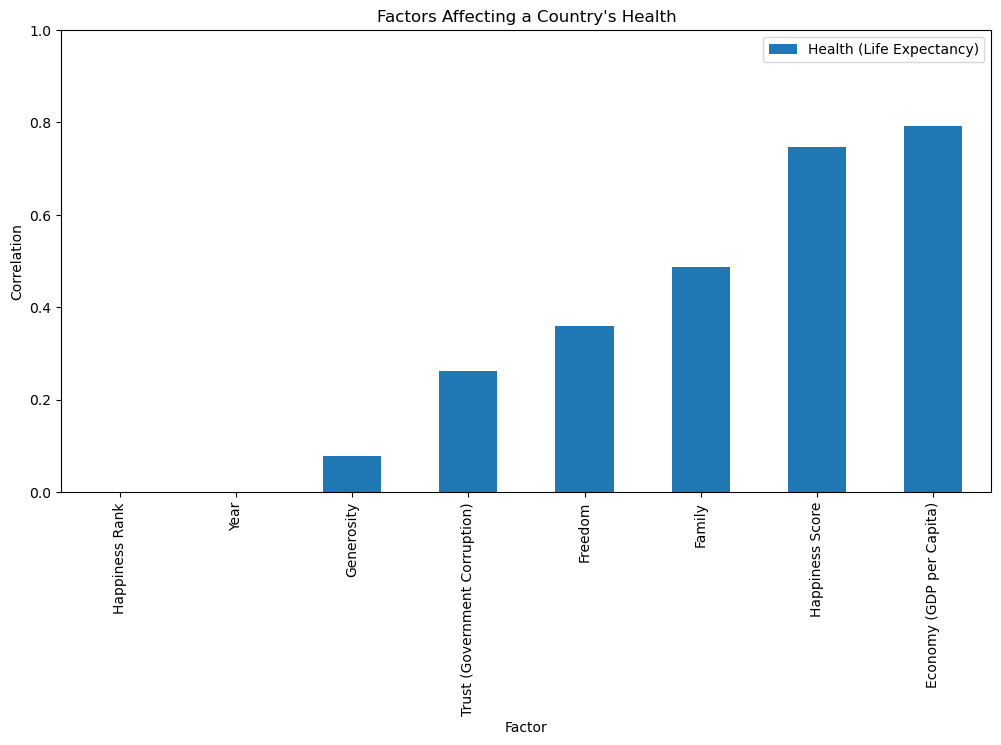

In [205]:
#your solution
#What factors affect a country's health the most?
factors = data.corr().loc['Health (Life Expectancy)'].to_frame()
factors = factors.loc[(~factors.index.str.contains('Health'))].sort_values(by = 'Health (Life Expectancy)')
factors.plot(kind='bar', figsize=(12, 6))
plt.title('Factors Affecting a Country\'s Health')
plt.xlabel('Factor')
plt.ylabel('Correlation')
plt.ylim((0, 1))
plt.show()

Hence, state your observations/conclusion.

<div class="alert alert-block alert-info">

Excluding Happiness rank and Year, the country's economy has the highest effect on a country's health.
    
</div>

#### f) We discussed the pairplot in the notes. In contrast to the `sns.pairplot` function, `sns.PairGrid` is a class which means that it does not automatically fill in the plots for us. Instead, we create a class instance and then we map specific functions to the different sections of the grid. 

Read more about PairGrid and how to use it: https://seaborn.pydata.org/generated/seaborn.PairGrid.html

Plot a relevant PairGrid to visualize the data in this question.

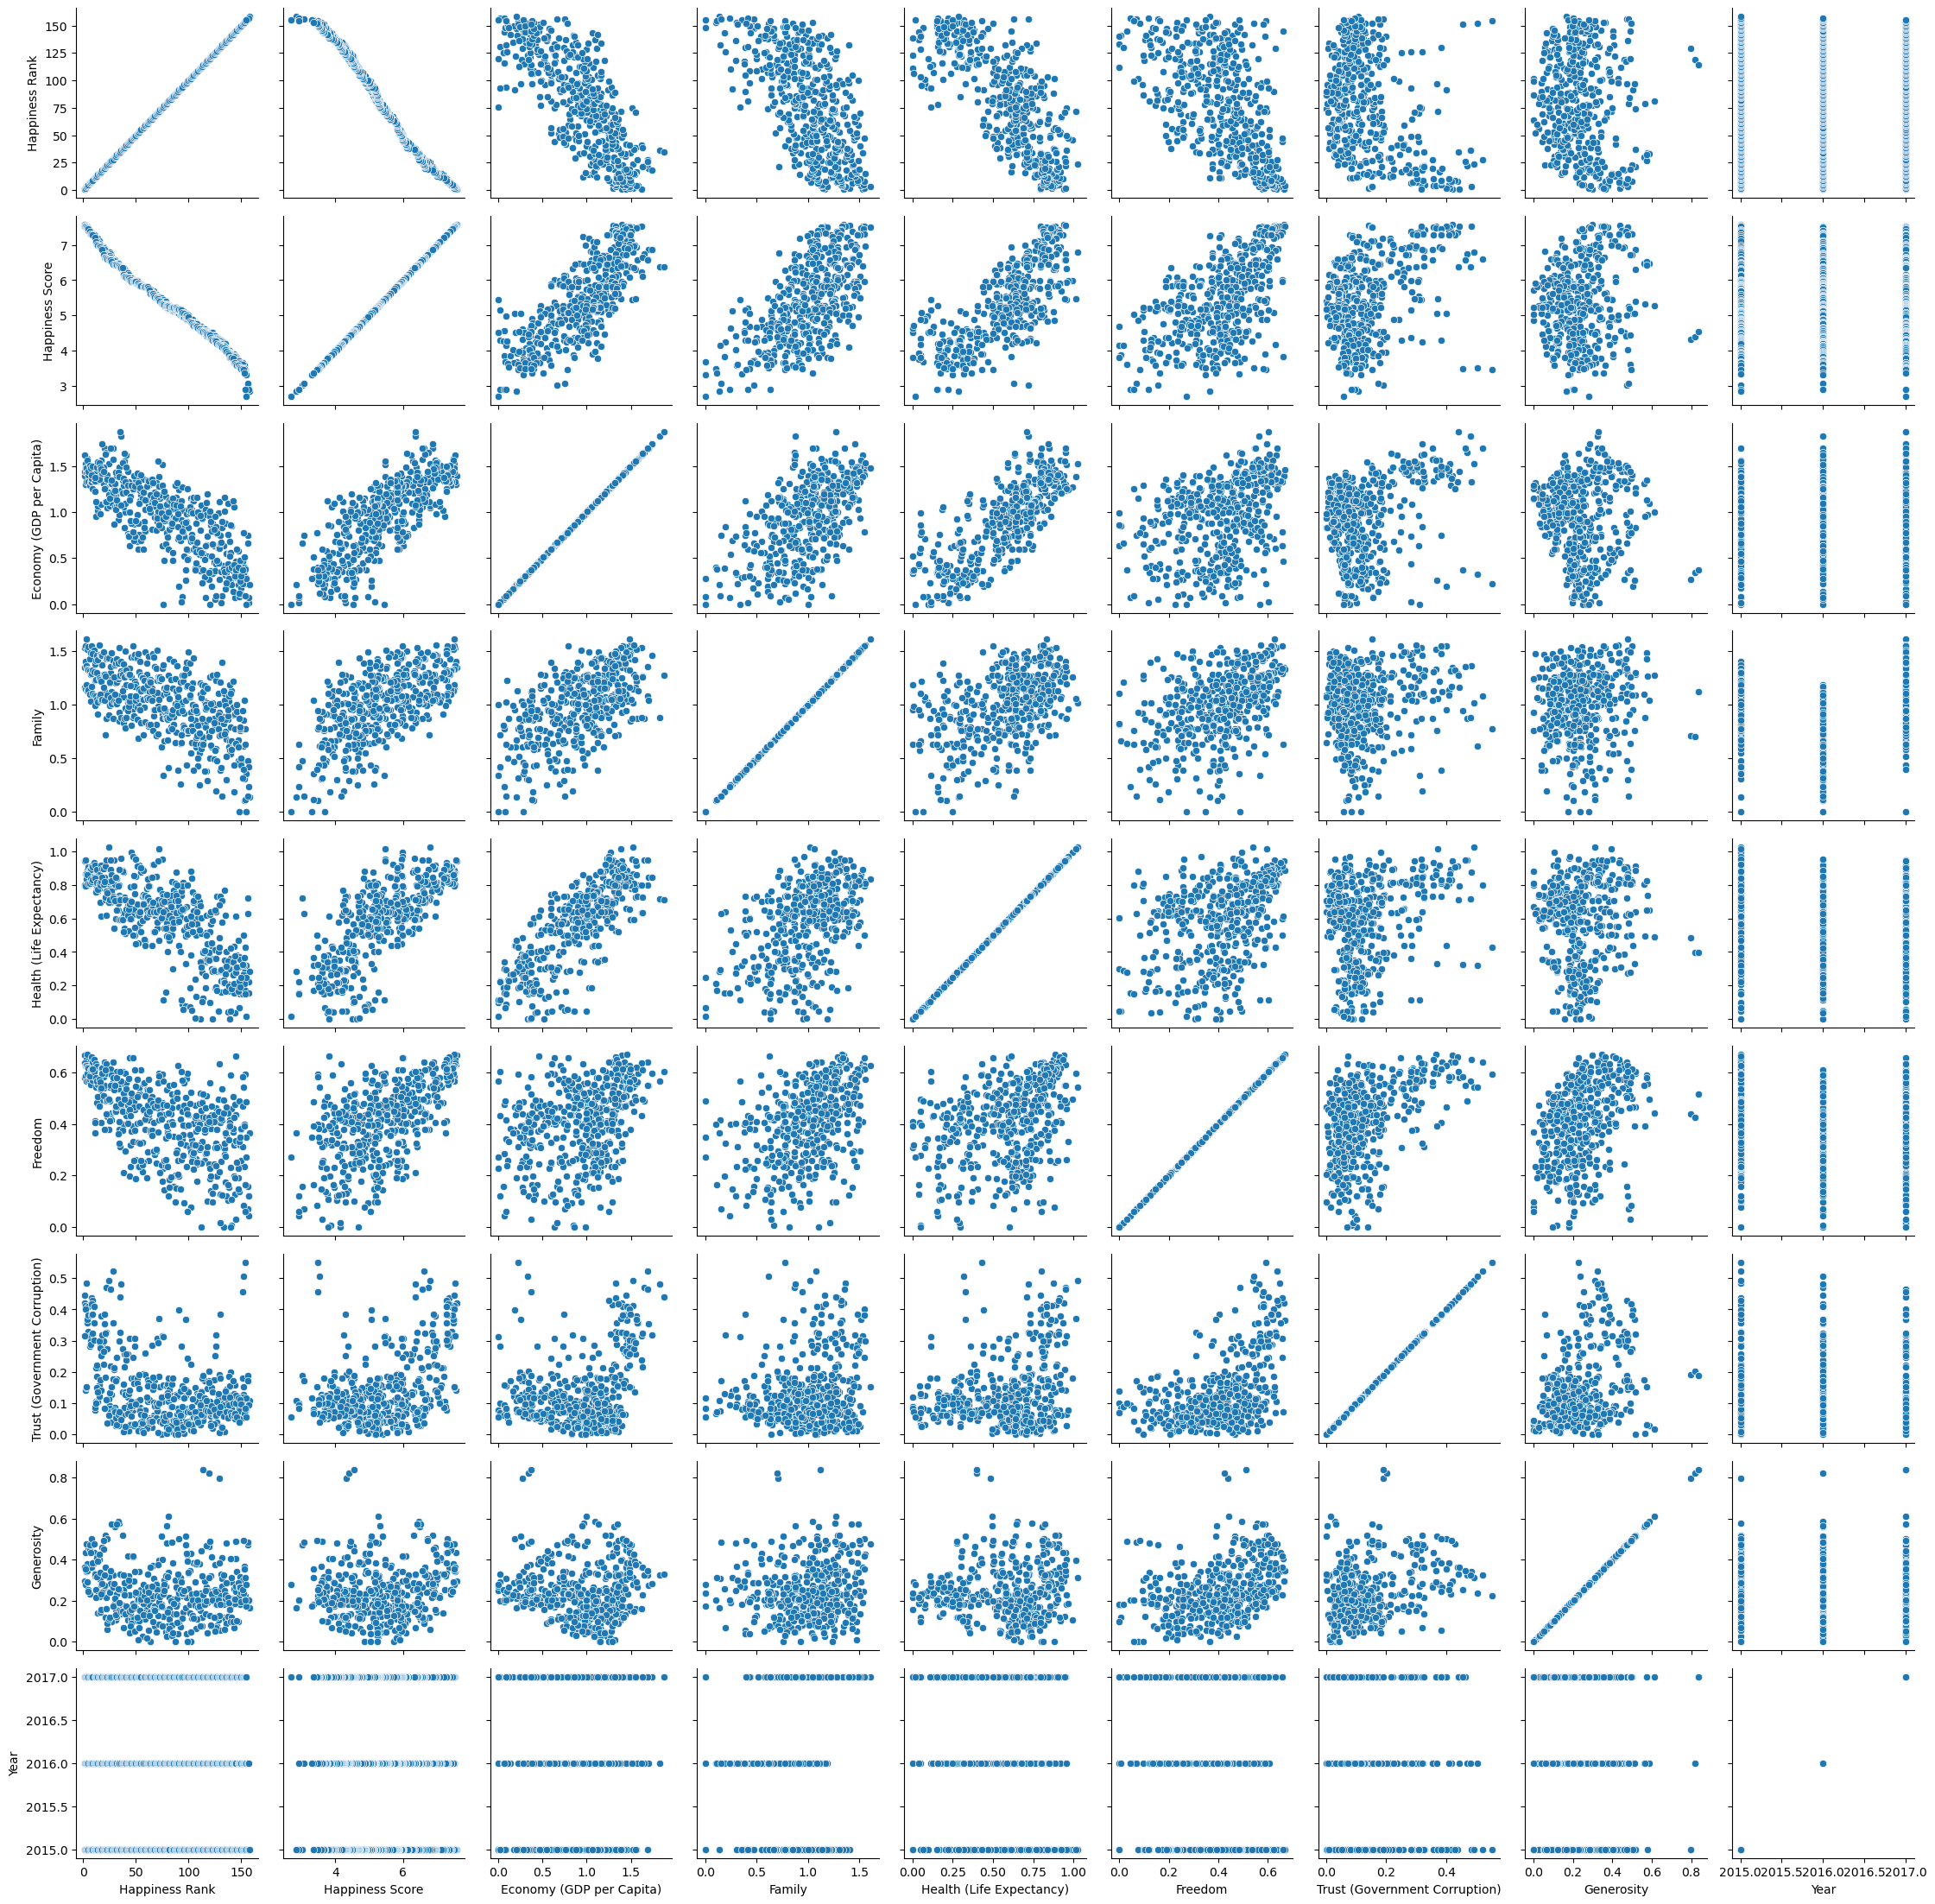

In [207]:
#your solution
g = sns.PairGrid(data)
g.map(sns.scatterplot)
g

Do some customization to the PairGrid such that the diagonal will display the respective 5-number summary instead of the histogram.

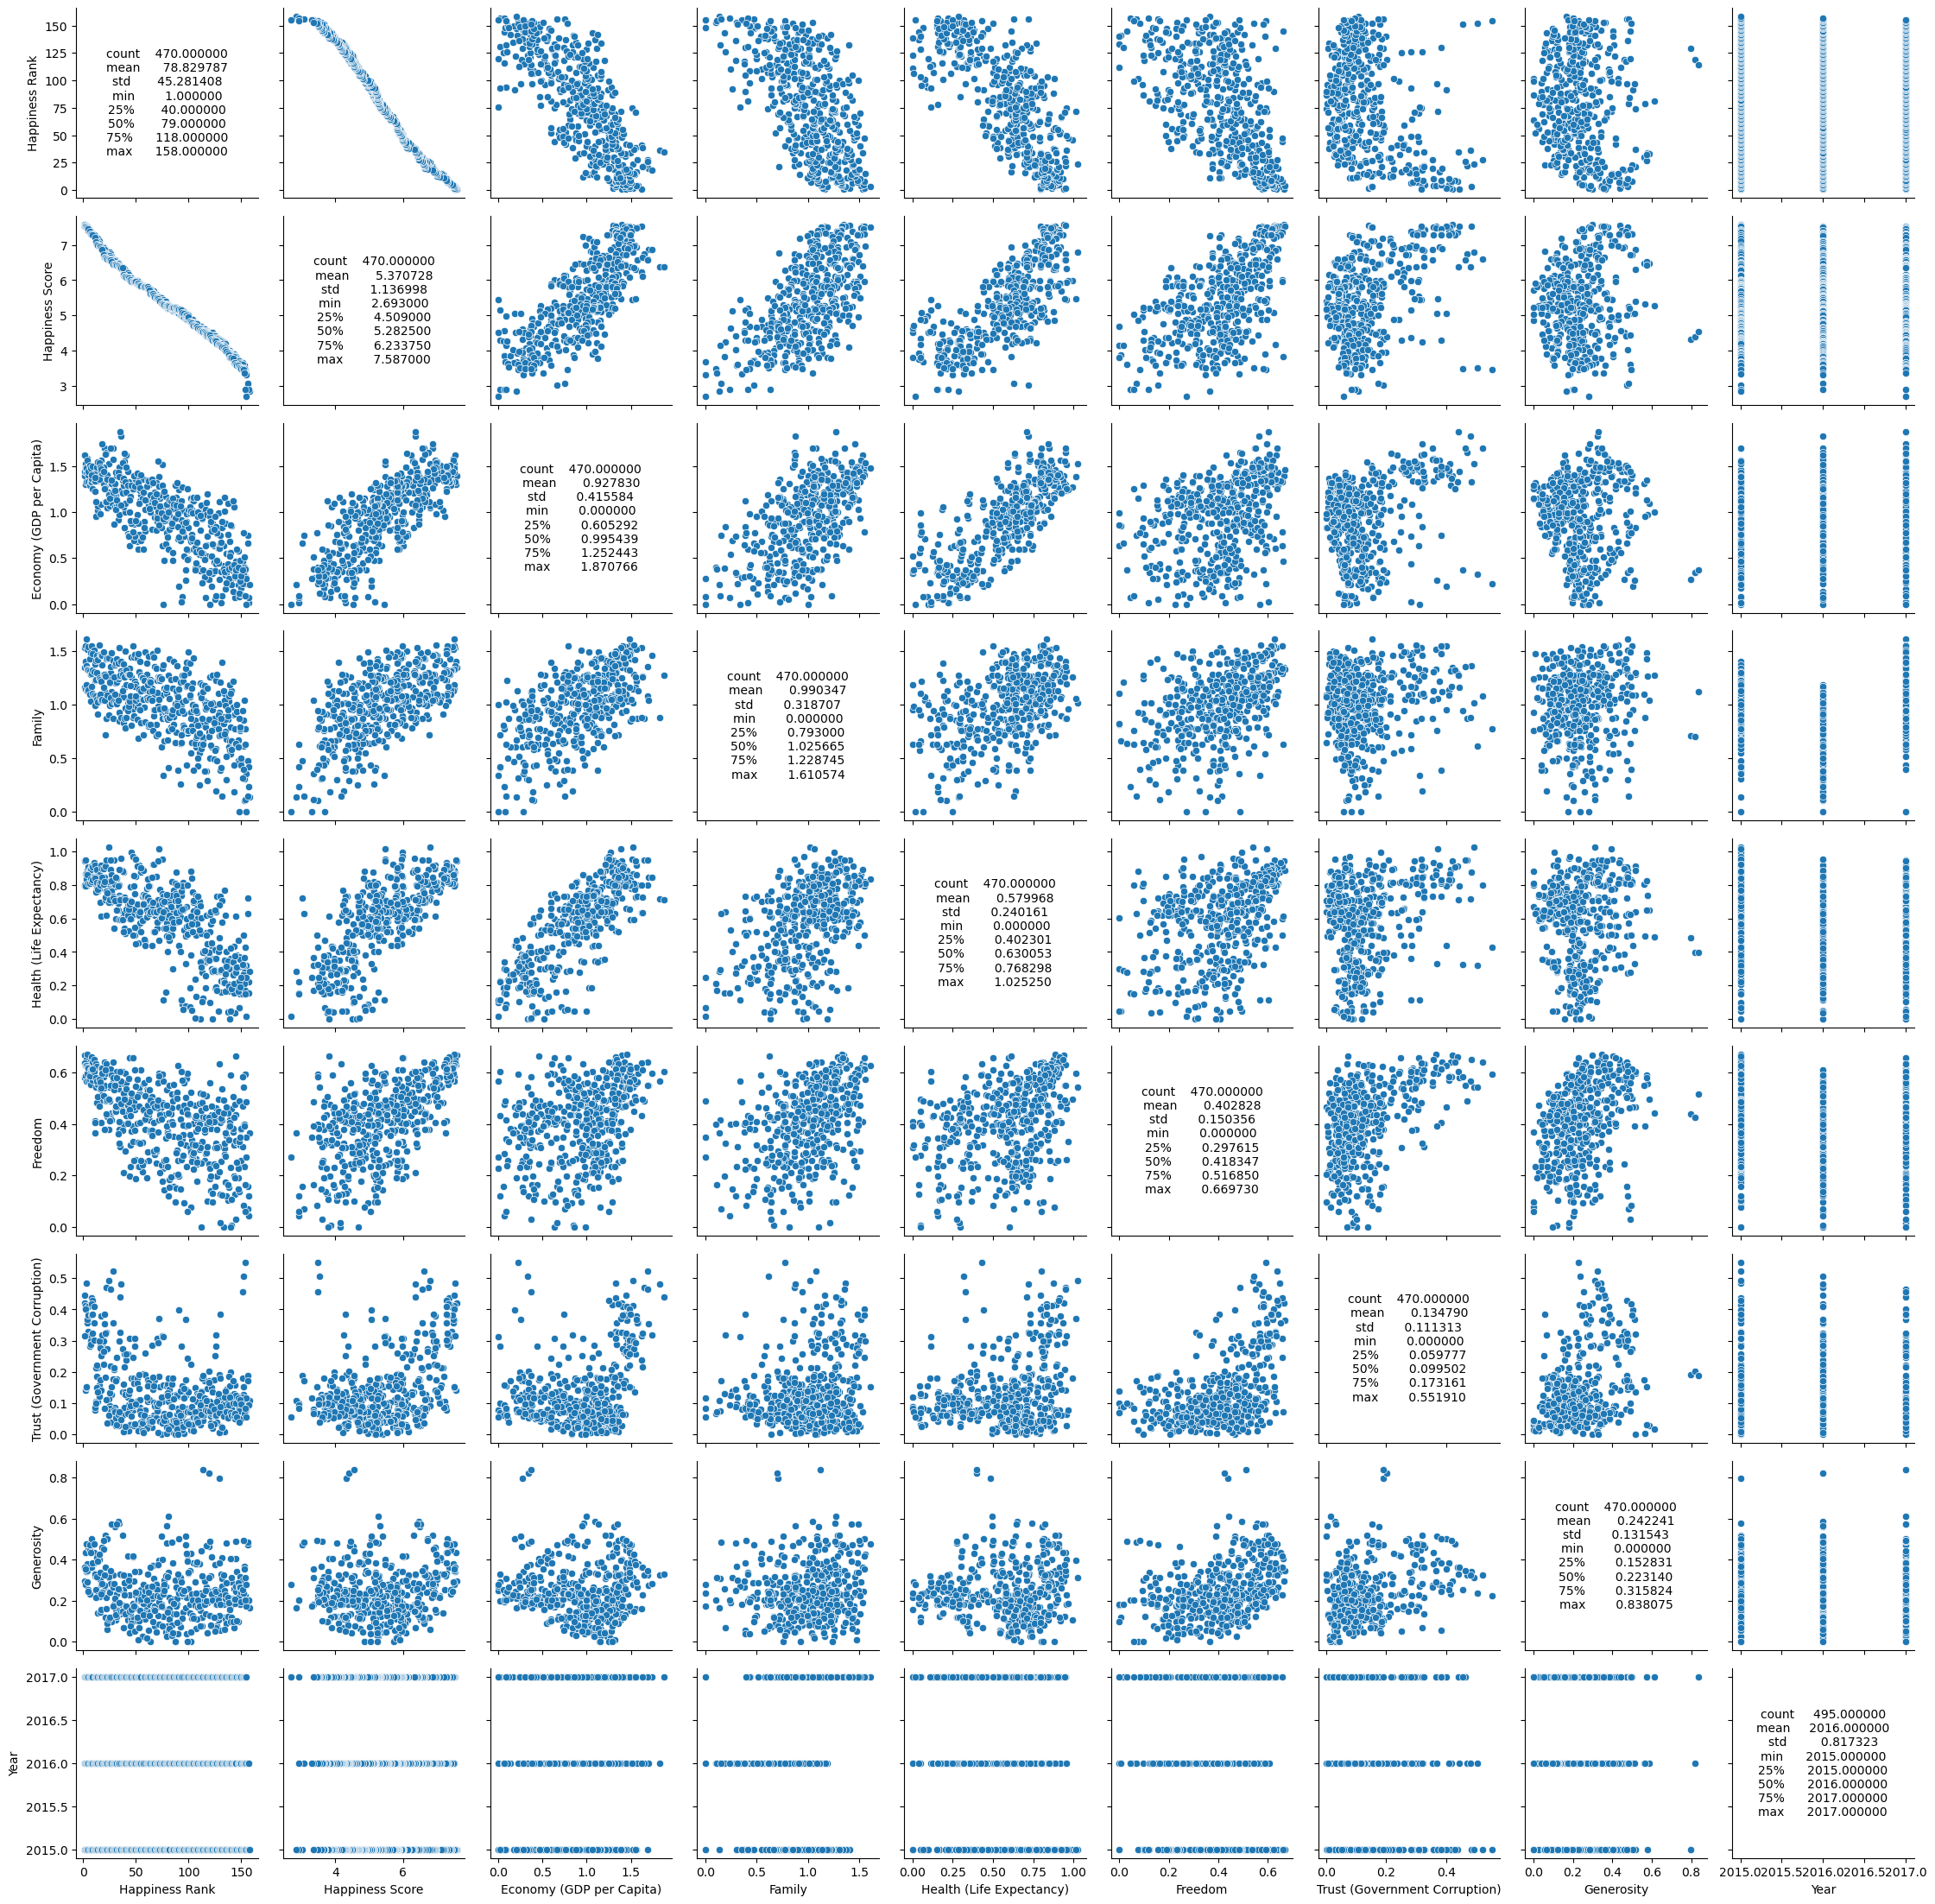

In [ ]:
#your solution
def summ(data, **kwargs):
    data = pd.Series(data)
    ax = plt.gca()
    ax.annotate(data.describe().to_string(), xy=(0.5,0.5), xycoords='axes fraction', ha='center', va='center')

g = sns.PairGrid(data)
g.map_diag(summ)
g.map_offdiag(sns.scatterplot)
g

#### g) There is another class called the `sns.FacetGrid` which maps a dataset onto multiple axes arrayed in a grid of rows and columns that correspond to levels of variables in the dataset. 

Read more about FacetGrid and how to use it: https://seaborn.pydata.org/generated/seaborn.FacetGrid.html

Plot a relevant FacetGrid to visualize the relationship between Happiness Score and GDP by Region (row) and Year (Column).

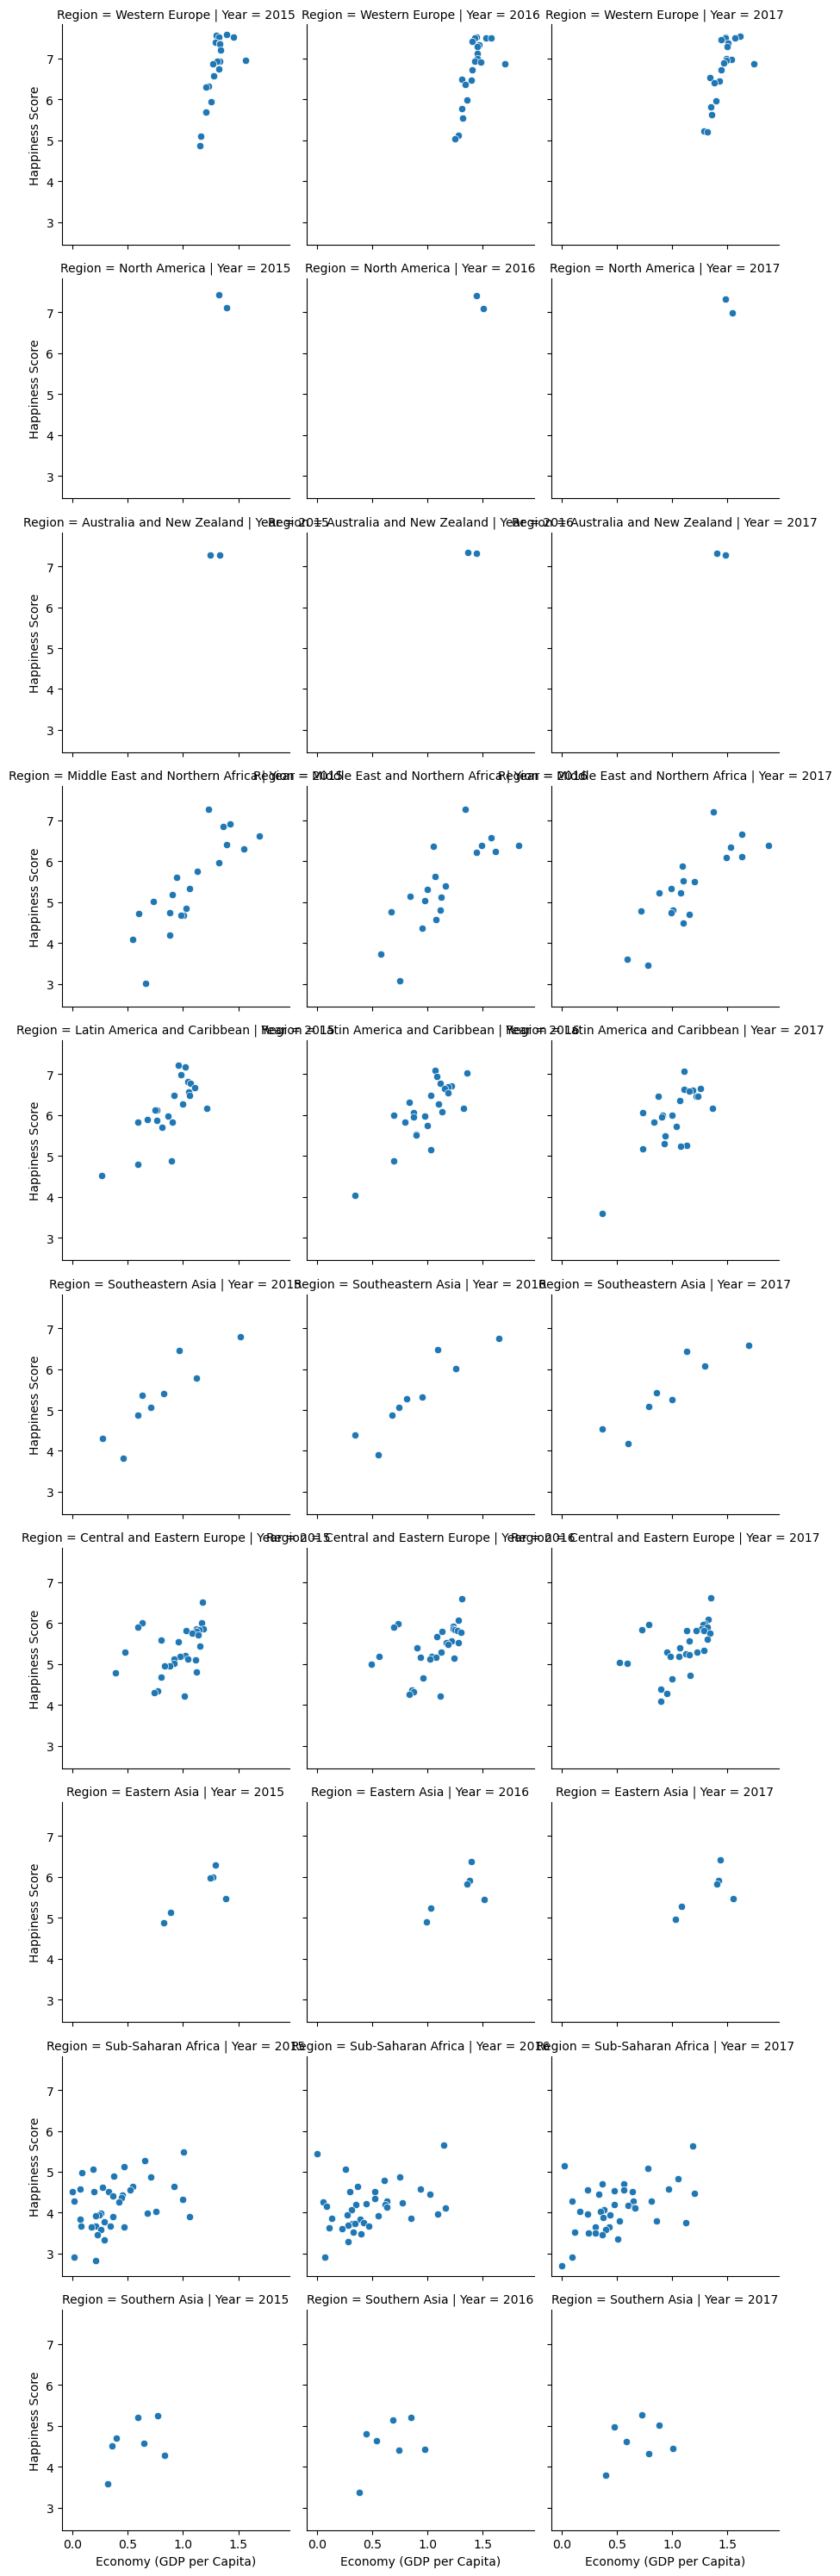

In [ ]:
#your solution
g = sns.FacetGrid(data, col = 'Year',  row = 'Region')
g.map(sns.scatterplot, 'Economy (GDP per Capita)', 'Happiness Score') 

Hence, state the differences between pairplot, PairGrid and FacetGrid.

<div class="alert alert-block alert-info">

PairGrid plots a relationship using each column of a dataset against every column in a dataset.

FacetGrid plots a relationship of 2 values with every combination of 2 chosen variables
    
</div>

## Q3

The data below shows the keyword search on the terms 'diet', 'gym' and 'finance' on Google over time.

In [336]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
df = pd.read_csv('Lab7iiQ3.csv', skiprows=1)
df.columns = ['month', 'diet', 'gym', 'finance']
df.head()

,month,diet,gym,finance
0,2004-02,75,26,49
1,2004-03,67,24,47
2,2004-04,70,22,48
3,2004-05,72,22,43
4,2004-06,64,24,45


#### a) Without making any changes to the dataframe, try to plot a trend graph for the data using the lineplot function in seaborn. Note that the 3 lines should be displayed in the same graph. The y-axis will be the frequency, and x-axis will be the months.

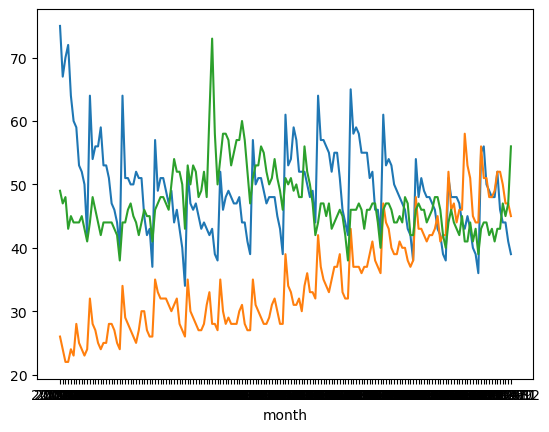

In [337]:
#your solution
sns.lineplot(data = df, x = df.month, y = df.diet, )
sns.lineplot(data = df, x = df.month, y = df.gym)
sns.lineplot(data = df, x = df.month, y = df.finance)
plt.ylabel('')
plt.show()

What do you notice about the x-axis of your plot?

<div class="alert alert-block alert-info">

The x-axis displays every single month
    
</div>

#### b) Now, update month into a datetime attribute. Next, reindex the df such that month is the index. Display the df.

In [338]:
#your solution
df.month = pd.to_datetime(df['month'])
df.set_index(keys = 'month')

,diet,gym,finance
month,,,
2004-02-01,75,26,49
2004-03-01,67,24,47
2004-04-01,70,22,48
2004-05-01,72,22,43
2004-06-01,64,24,45
...,...,...,...
2017-08-01,46,52,43
2017-09-01,44,50,47
2017-10-01,44,47,45


#### c) Plot a new trend graph using the dataframe from b) using the matplotlib `plot` function.

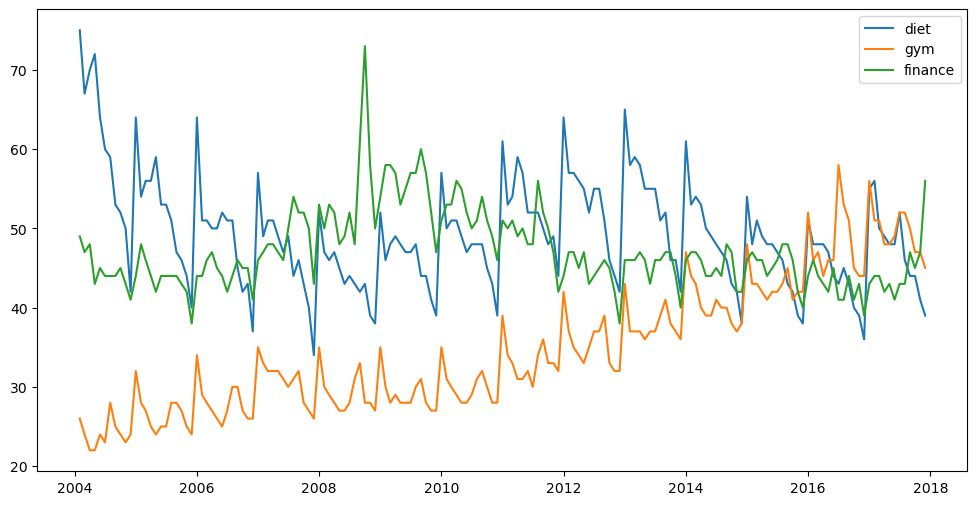

In [339]:
#your solution
plt.figure(figsize = (12, 6))
plt.plot(df.month, df.diet)
plt.plot(df.month, df.gym)
plt.plot(df.month, df.finance)
plt.legend(['diet', 'gym', 'finance'])
plt.show()

Compare the differences between the graph from (a) and (c).

<div class="alert alert-block alert-info">

Graph in a displays every single month and has no legend while graph in c displays by years in the axis and does not show every month, while still showing it in the graph and has a legend.
    
</div>

#### d) We would now like to identify trends in the time series for the 3 searches. One popular way is by rolling average. Plot a respective trend graph using rolling average method for each of the 3 searches in a single plot.

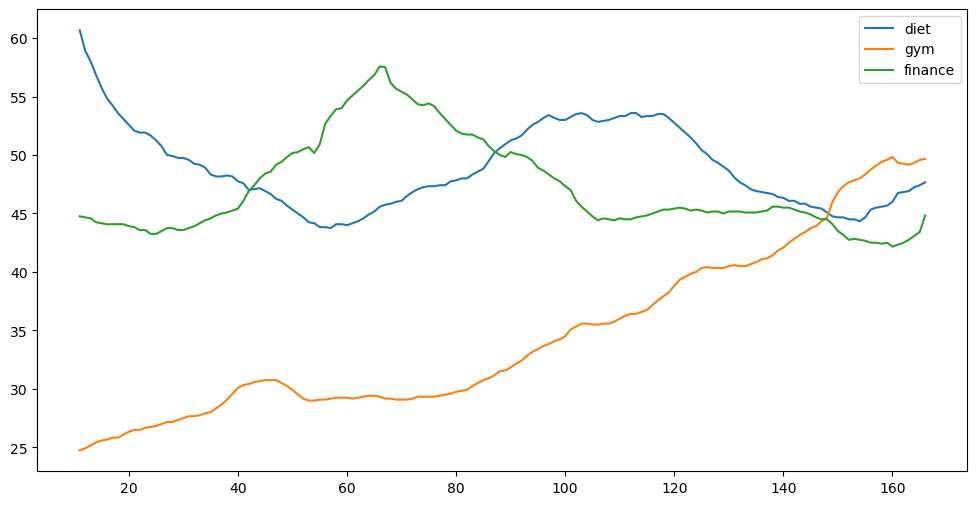

In [340]:
#your solution
df['dietroll'] = df.diet.rolling(window = 12).mean()
df['gymroll'] = df.gym.rolling(window = 12).mean()
df['financeroll'] = df.finance.rolling(window = 12).mean()
df[['dietroll', 'gymroll', 'financeroll']].plot(kind='line', figsize=(12,6))
plt.legend(['diet', 'gym', 'finance'])
plt.show()

Key in your observations for each graph.

<div class="alert alert-block alert-info">

Rolling average of gym increased from about 25 to 50 over the years

Rolling average of diet decreased then increased and decreased again from 60 to 45

Rolling average of finance increased then decreased then plateaued from 45 to 45
    
</div>

#### e) Is there any seasonal flunctations in the time series data? How would you investigate this?

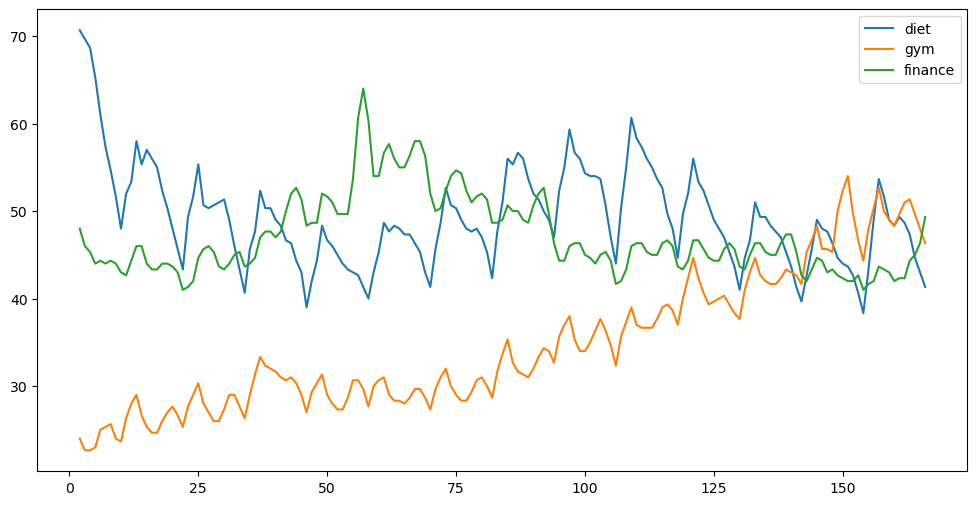

In [341]:
#your solution
#Use window of 3 since each season is around 3 months
df['dietroll'] = df.diet.rolling(window = 3).mean()
df['gymroll'] = df.gym.rolling(window = 3).mean()
df['financeroll'] = df.finance.rolling(window = 3).mean()
df[['dietroll', 'gymroll', 'financeroll']].plot(kind='line', figsize=(12,6))
plt.legend(['diet', 'gym', 'finance'])
plt.show()

Key in your observations for each graph.

<div class="alert alert-block alert-info">

double click to type your answer here
    
</div>

#### f) Plot a time series heatmap for the 'diet' trend. The x-axis represents the months (from 1 to 12) and the y-axis represents the years. 

C:\Users\user\AppData\Local\Temp\ipykernel_24836\1756572870.py:4: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  data_pivot = df.pivot('year', 'month', 'diet')


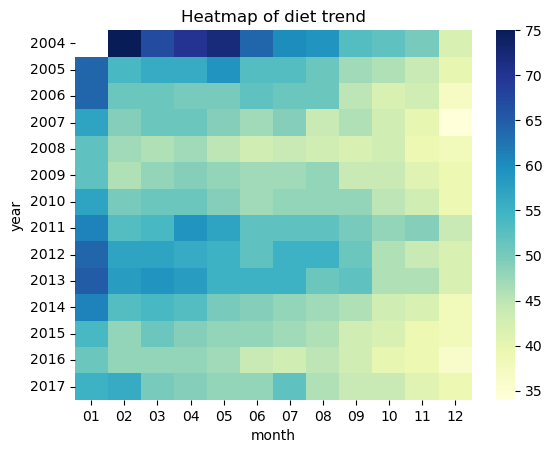

In [342]:
#your solution
df['year'] = df.month.dt.strftime('%Y')
df['month'] = df.month.dt.strftime('%m')
data_pivot = df.pivot('year', 'month', 'diet')
sns.heatmap(data_pivot, cmap='YlGnBu')
plt.title('Heatmap of diet trend')
plt.show()

Key in your observations for the graph.

<div class="alert alert-block alert-info">

Diet frequency decreases over the months of a year. 

Diet frequency decreased over the years, except for a spike in around 2011 to 2013
    
</div>